In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import so

## Load the data

In [2]:
df = so.load_data()
so.did_prepare_data(df)
print(df.info())
    
questions = so.questions(df)
answers = so.answers(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5997763 entries, 0 to 5997762
Data columns (total 20 columns):
 #   Column            Dtype         
---  ------            -----         
 0   PostTypeId        int64         
 1   AcceptedAnswerId  float64       
 2   CreationDate      datetime64[ns]
 3   Score             int64         
 4   ViewCount         float64       
 5   AnswerCount       float64       
 6   CommentCount      int64         
 7   FavoriteCount     float64       
 8   OwnerUserId       float64       
 9   Title             object        
 10  Tags              object        
 11  line_count        float64       
 12  T                 int64         
 13  P                 int64         
 14  W                 int64         
 15  code              object        
 16  text              object        
 17  log_lc            float64       
 18  D                 int32         
 19  date              datetime64[ns]
dtypes: datetime64[ns](2), float64(7), int32(1), in

In [3]:
# Tags
filenames = ['java_c.csv', 'python_c.csv', 'web_c.csv']
tags = ['java', 'python', 'web']

tag_dfs = {}
for tag, filename in zip(tags, filenames):
        print(f'Loading: {tag}')
        tag_df = so.load_data(f'data/csv/tags/{filename}')
        so.did_prepare_data(tag_df, 'tags')
        tag_dfs[tag] = tag_df

Loading: java
Loading: python
Loading: web


## Util functions

In [4]:
def clean(data):
    data = data.dropna(subset=['OwnerUserId']).copy()
    data['OwnerUserId'] = data['OwnerUserId'].astype(int)
    return data

In [5]:
def users():
    users = pd.read_csv('data/csv/users/users.csv')
    return users

In [6]:
def join(data, users):
    posts_users = data.merge(users, how='inner', left_on='OwnerUserId', right_on='Id')
    return posts_users

In [14]:
def freq_dist(data):
    counts = data.groupby('OwnerUserId').size()
    freq = counts.value_counts(sort=False)
    sns.barplot(x=freq.index, y=freq.values, errorbar=None)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Number of posts')
    plt.ylabel('Number of users')
    plt.title('Posting frequency distribution')
    plt.show()

    return counts

In [46]:
def groups(data, counts):
    sorted = counts.sort_values()
    vals = sorted.to_numpy()
    cum = np.cumsum(vals)
    total = cum[-1]
    cut1 = np.searchsorted(cum, total / 4, side='left')
    cut2 = np.searchsorted(cum, 3 * total / 4, side='left')
    sporadic = sorted.iloc[:cut1]
    regular =  sorted.iloc[cut1:cut2]
    power = sorted.iloc[cut2:]

    sporadic_users = sporadic.index
    regular_users = regular.index
    power_users = power.index

    sporadic_events = data[data['OwnerUserId'].isin(sporadic_users)]
    regular_events = data[data['OwnerUserId'].isin(regular_users)]
    power_events = data[data['OwnerUserId'].isin(power_users)]

    return sporadic_events, regular_events, power_events

In [27]:
def regression(data, outcome):
    start_dates, masks = so.rolling_window_masks(data, data_column='date', normalized=True, window_days=30)    

    X, y = so.did_design_matrix(f'{outcome}_bar', data)
    res = so.did_wls(data, X, y, masks, start_dates, outcome)
    return res

In [28]:
users_df = users()

Processing: questions


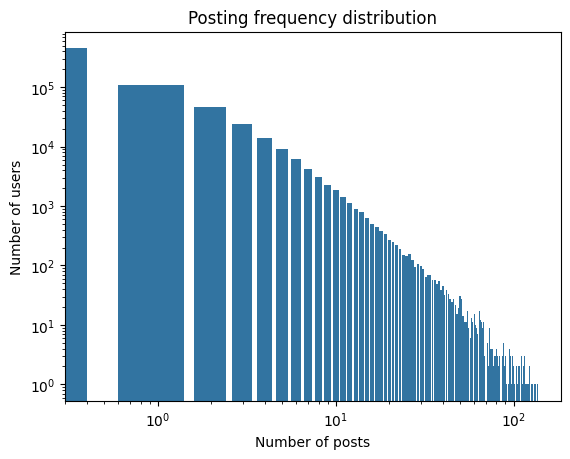

#Events: 484134
#Users: 344659
P  T
0  0    144000
   1    200659
1  0     49425
   1     38567
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  1.0
Max:  0.06703482847533394
AUC:  0.0522826383497631


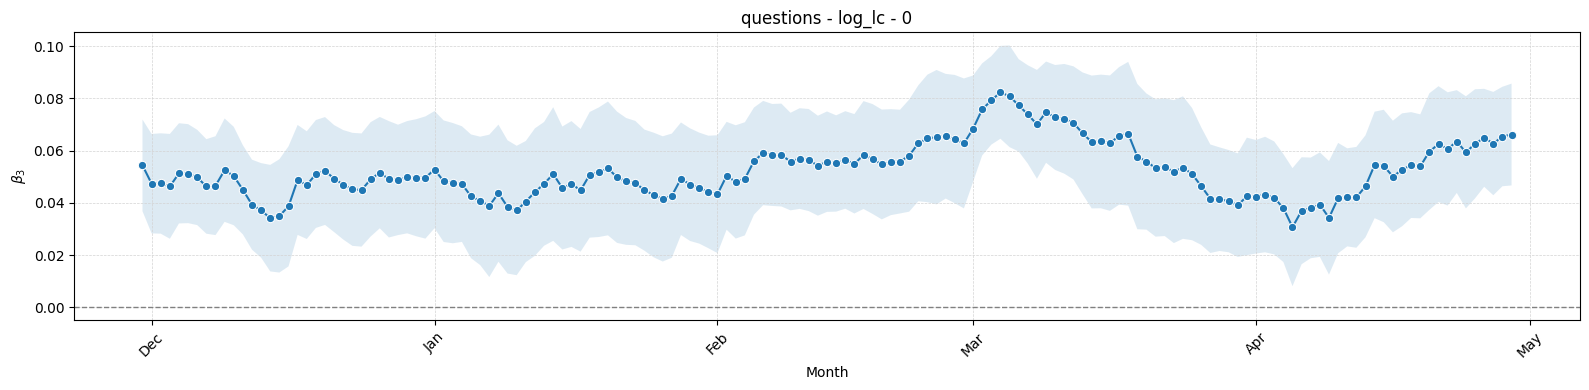

#Events: 988668
#Users: 309777
P  T
0  0    222833
   1    146055
1  0     83771
   1     58565
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.2185430463576159
Max:  0.022748389458157173
AUC:  0.014739691430933193


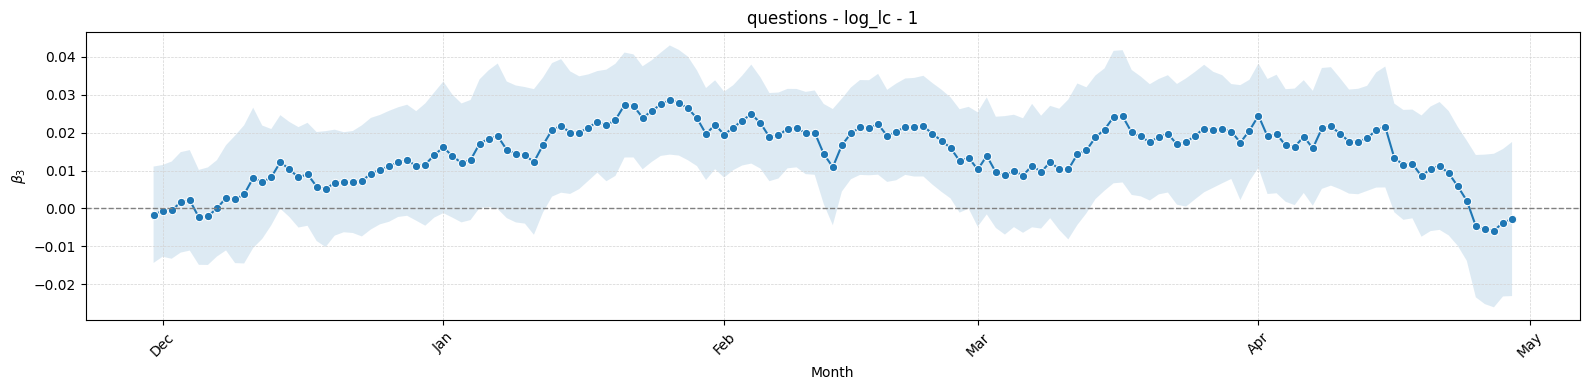

#Events: 540686
#Users: 26055
P  T
0  0    21135
   1    21290
1  0    18600
   1    15395
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.9072847682119205
Max:  0.04112703374082601
AUC:  0.032756053259813775


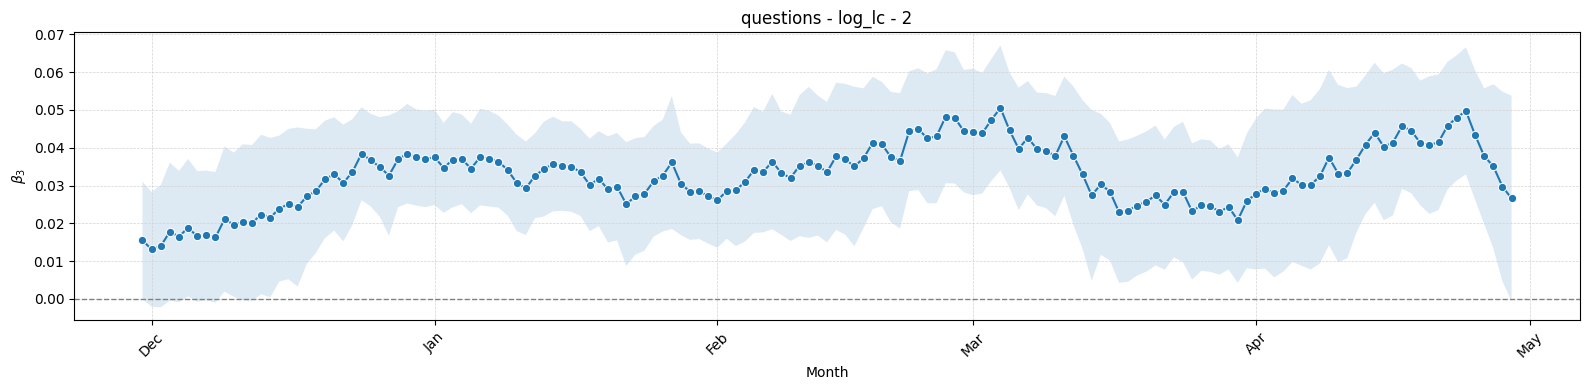

Processing: answers


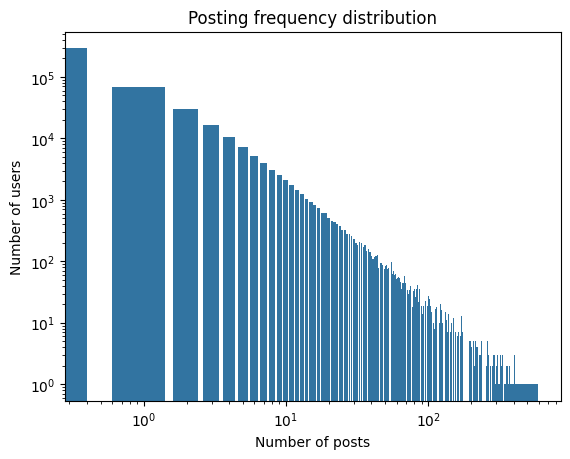

#Events: 658103
#Users: 367953
P  T
0  0    194563
   1    190715
1  0     58507
   1     44434
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  1.0
Max:  0.08693823652011654
AUC:  0.05569050046236436


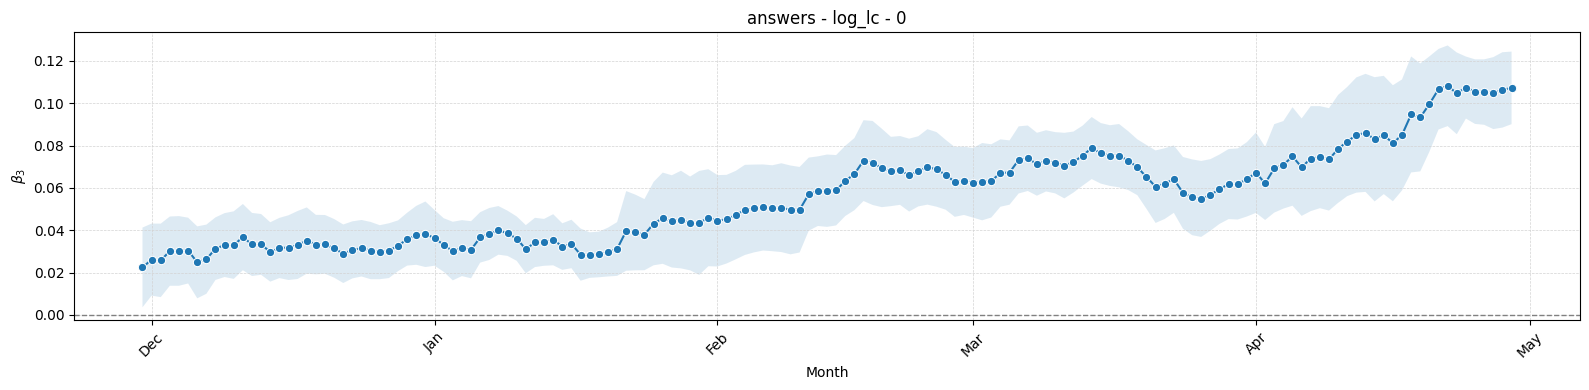

#Events: 1416702
#Users: 93699
P  T
0  0    69253
   1    67496
1  0    47198
   1    37822
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  1.0
Max:  0.05541294963129208
AUC:  0.047195525463538654


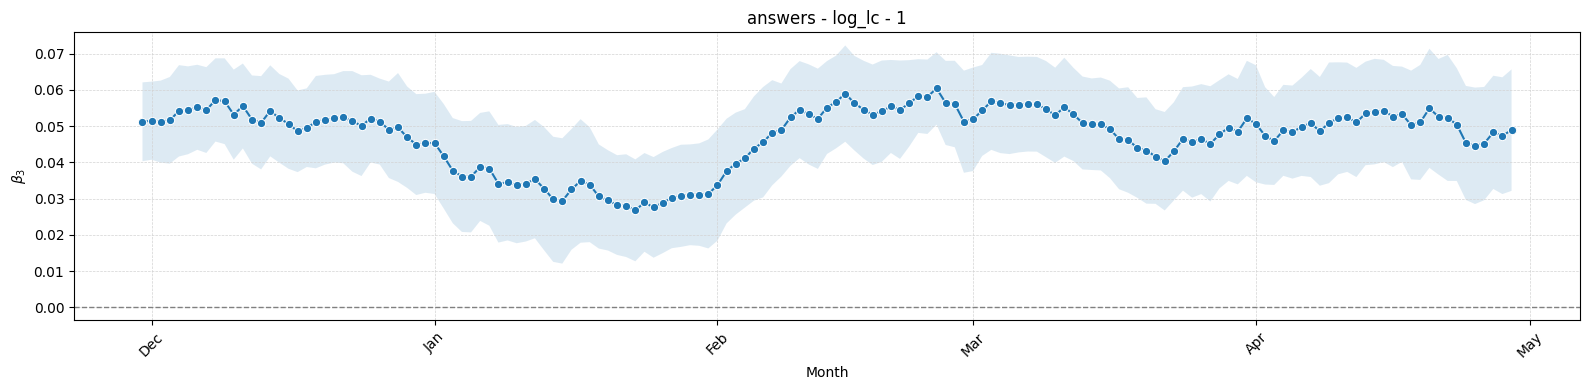

#Events: 784235
#Users: 1430
P  T
0  0    1297
   1    1369
1  0    1331
   1    1288
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.08609271523178808
Max:  0.021508660370373116
AUC:  0.005873178243976455


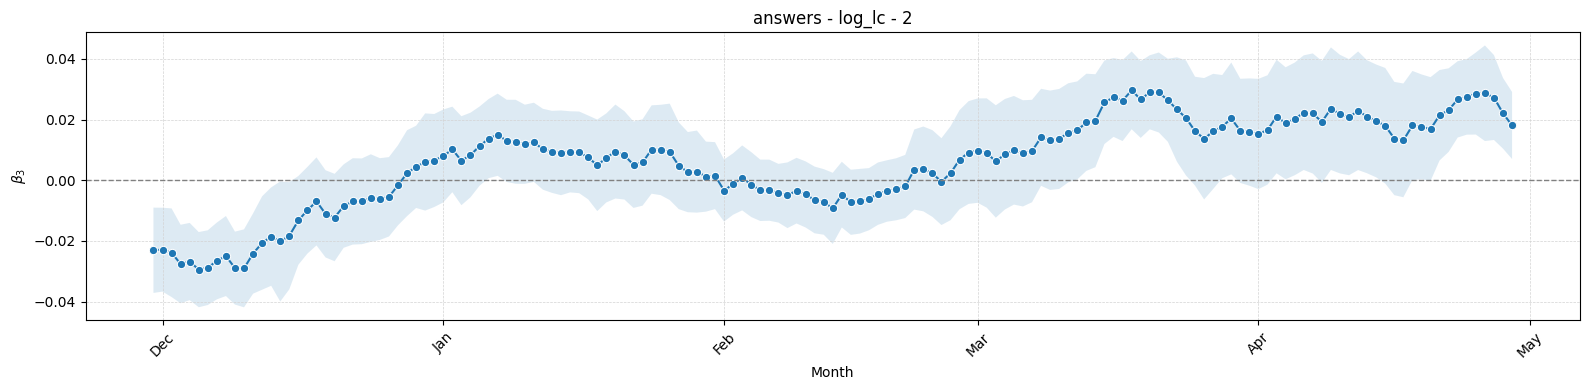

Processing: java


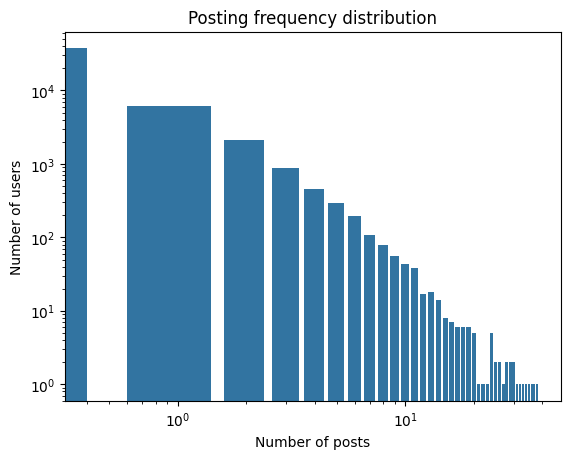

#Events: 21322
#Users: 17629
P  T
0  0    7909
   1    9720
1  0    1381
   1    1245
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.08609271523178808
Max:  0.1036931421859356
AUC:  0.033711597150755314


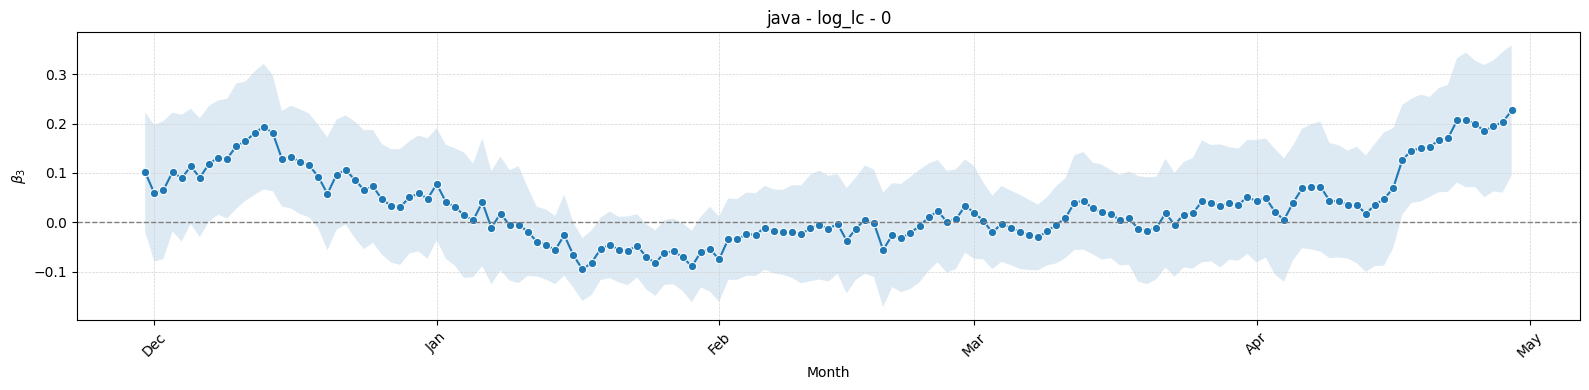

Processing: log_loc
Streak:  0.0728476821192053
Max:  0.10206363874720546
AUC:  -0.03915745524473645


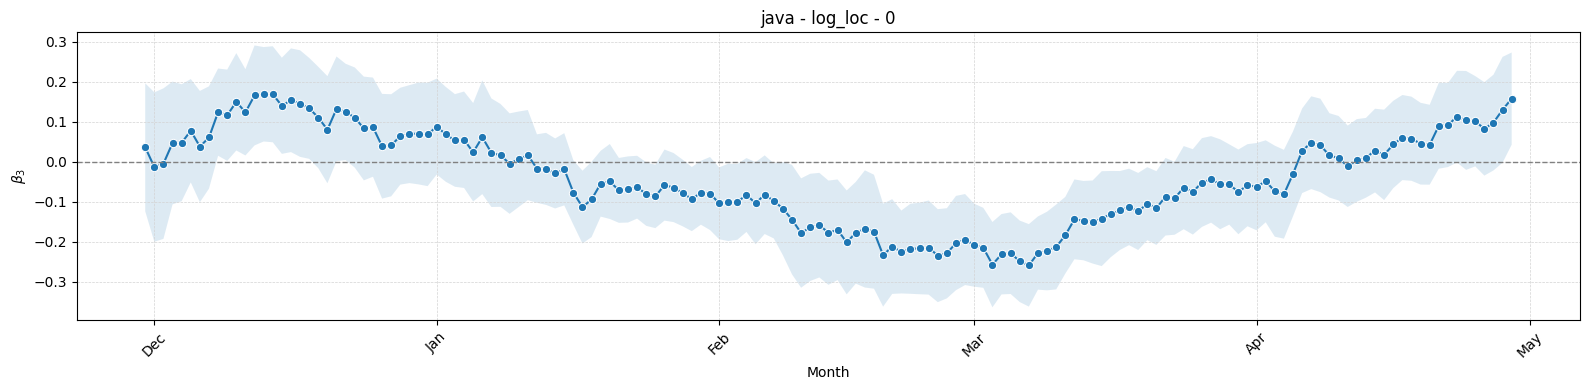

Processing: Medium
Streak:  0.19205298013245034
Max:  0.23458794481895617
AUC:  0.05271409532800717


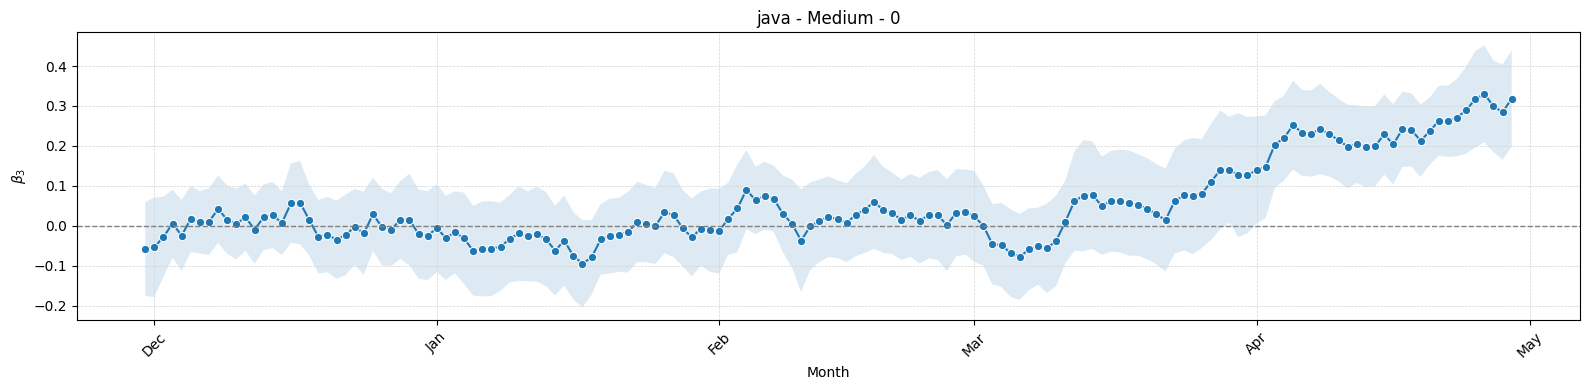

#Events: 43193
#Users: 27050
P  T
0  0    17194
   1    11129
1  0     3264
   1     1625
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.10596026490066225
Max:  0.10625207889386916
AUC:  0.055312678723403064


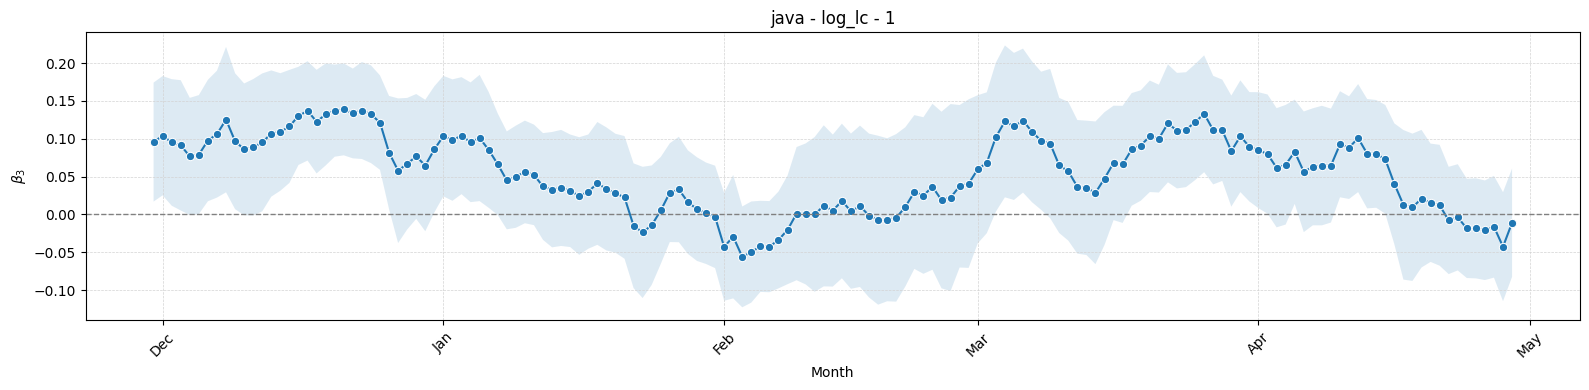

Processing: log_loc
Streak:  0.08609271523178808
Max:  0.1409682089439133
AUC:  0.04731657946202743


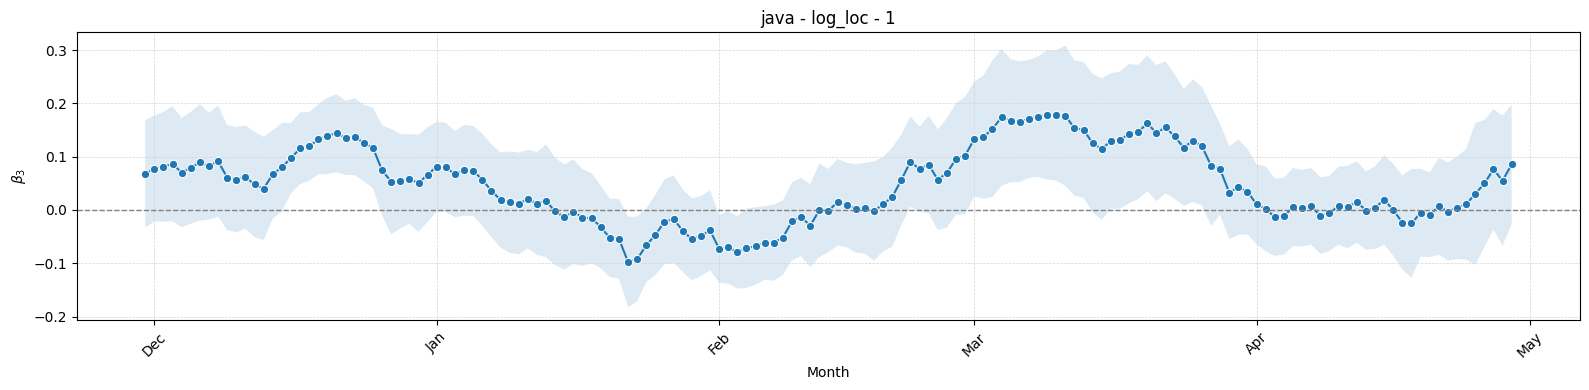

Processing: Medium
Streak:  0.06622516556291391
Max:  0.07976442759373531
AUC:  0.023294163585913345


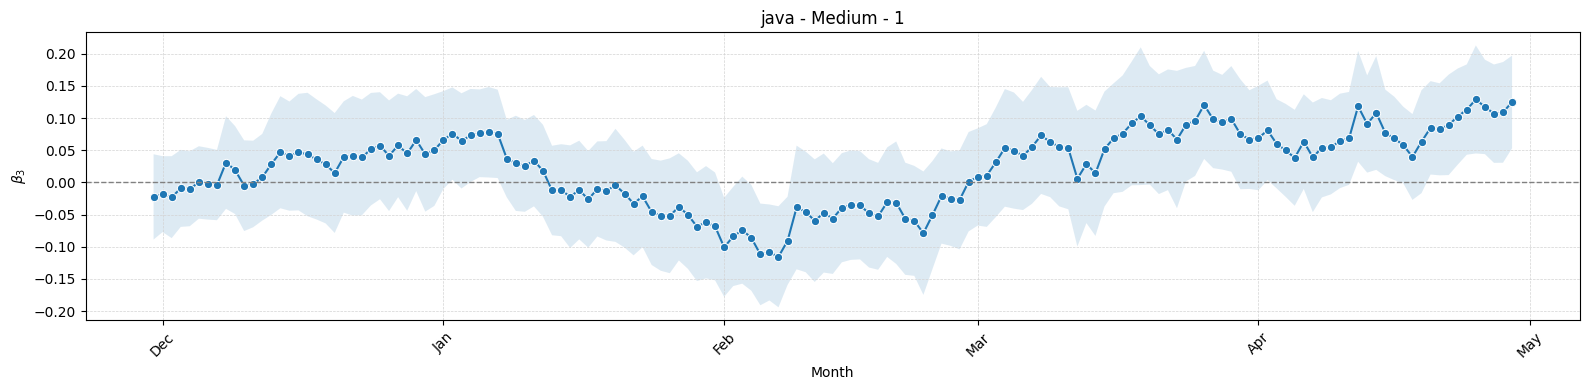

#Events: 24211
#Users: 3362
P  T
0  0    2520
   1    2016
1  0    1374
   1     917
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.17880794701986755
Max:  0.16943986167794334
AUC:  0.07848188191985789


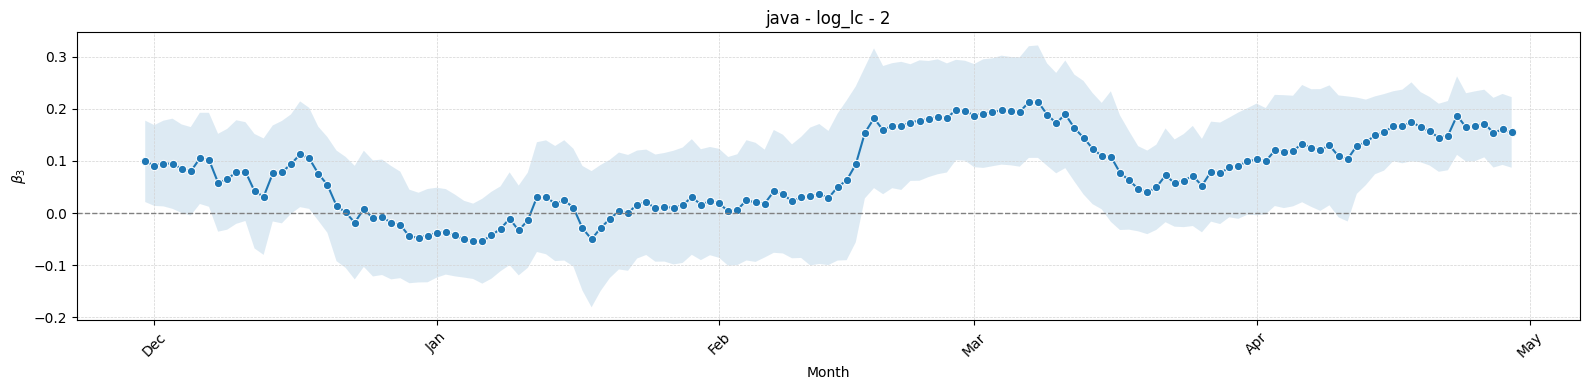

Processing: log_loc
Streak:  0.1986754966887417
Max:  0.17295706729260493
AUC:  0.045464402034298024


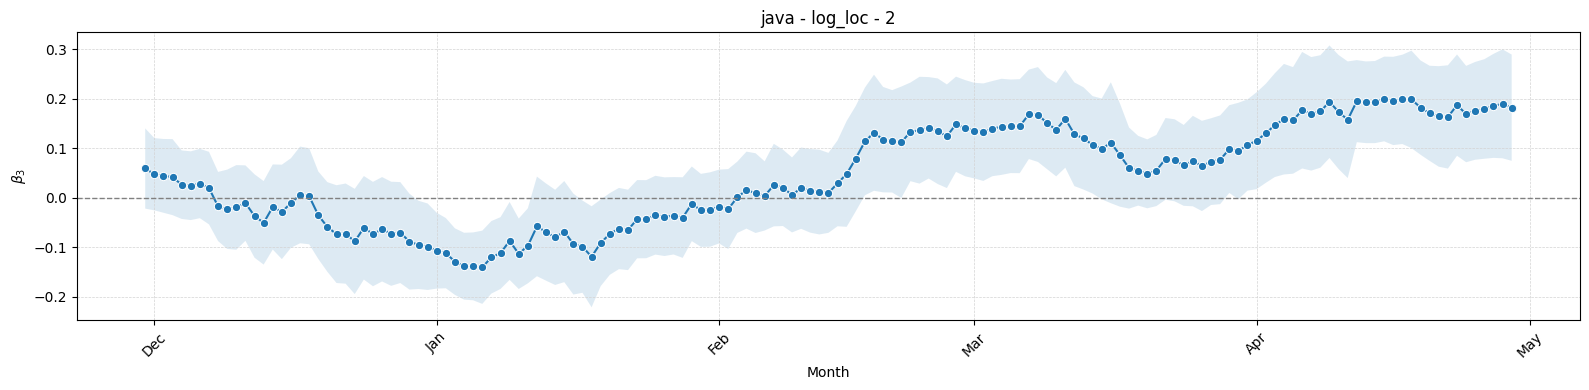

Processing: Medium
Streak:  0.13245033112582782
Max:  0.13094908993463686
AUC:  0.041835174132101235


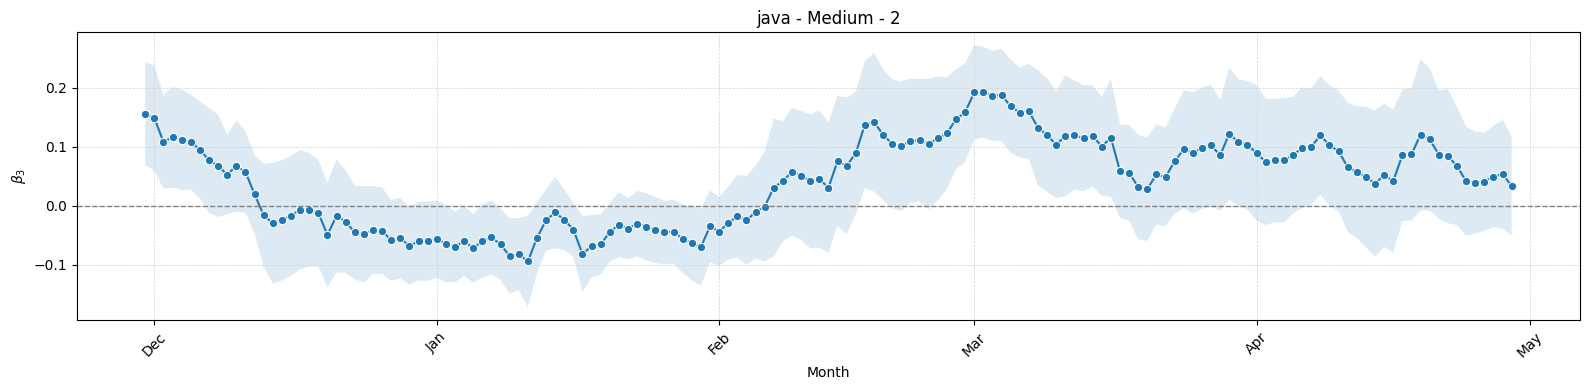

Processing: python


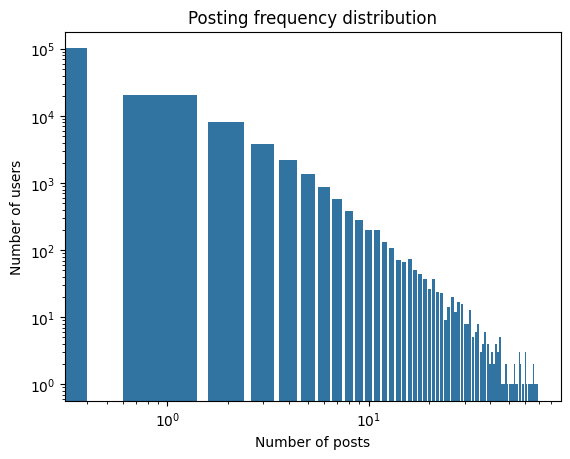

#Events: 76053
#Users: 60718
P  T
0  0    24638
   1    36080
1  0     5324
   1     4705
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.8410596026490066
Max:  0.1477349127911359
AUC:  0.11977648437411897


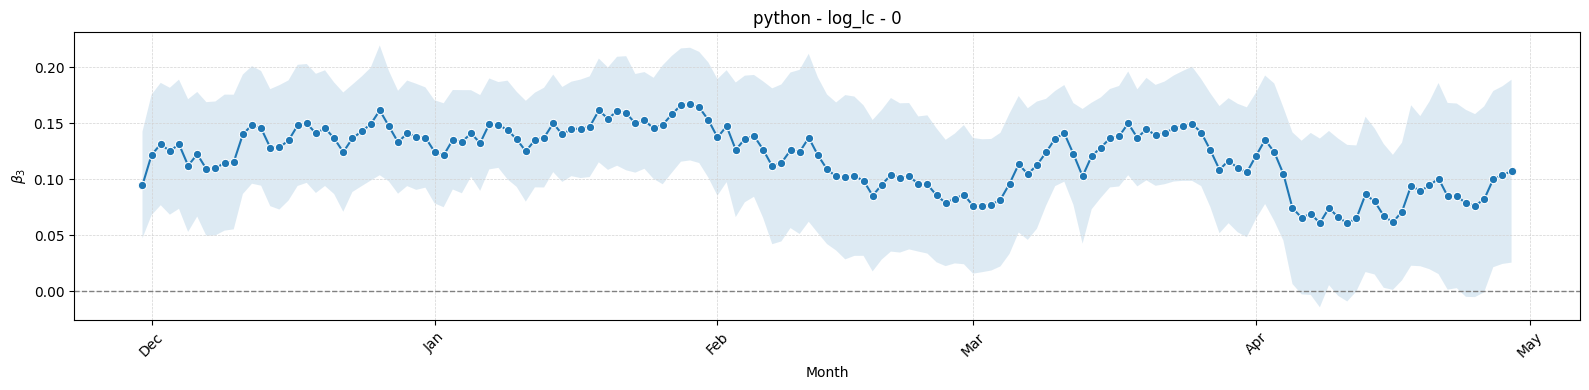

Processing: log_loc
Streak:  0.7417218543046358
Max:  0.10092860910234379
AUC:  0.08268321241457753


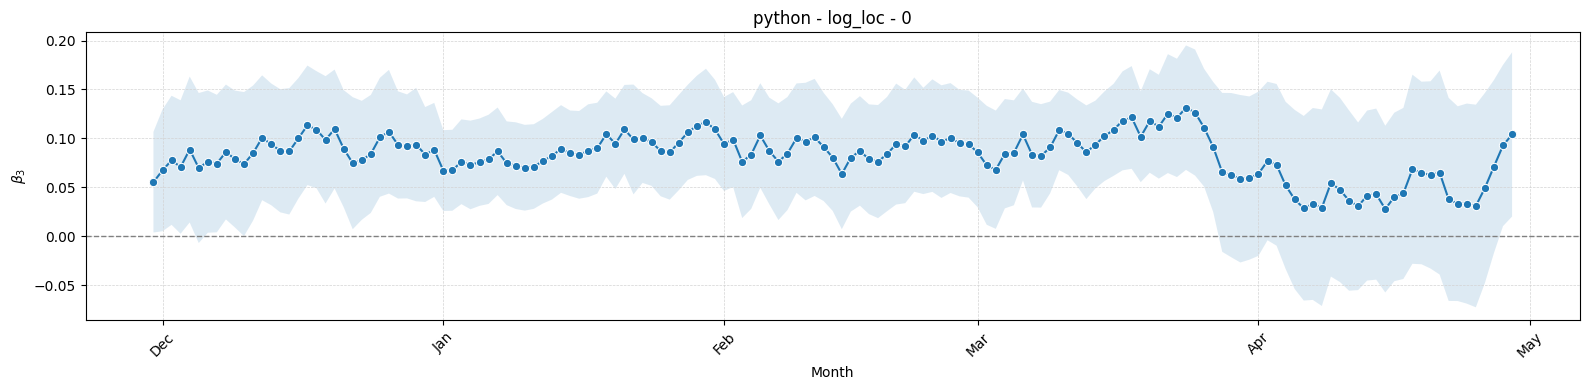

Processing: Medium
Streak:  0.18543046357615894
Max:  0.11161126097646552
AUC:  0.051291909837575325


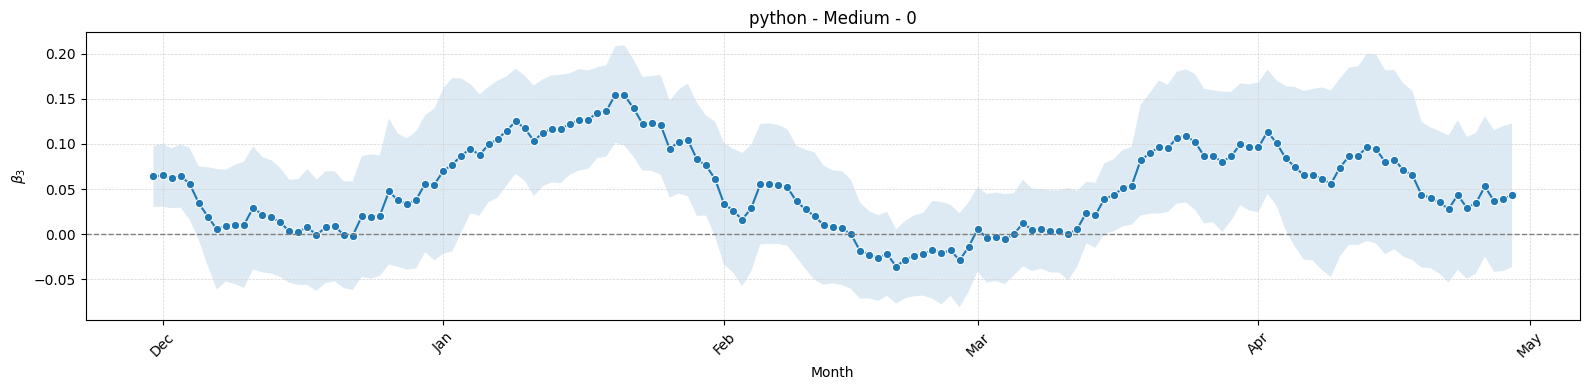

#Events: 158622
#Users: 73617
P  T
0  0    46684
   1    32896
1  0    12791
   1     7126
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.2251655629139073
Max:  0.08258507284179002
AUC:  0.044786078564741504


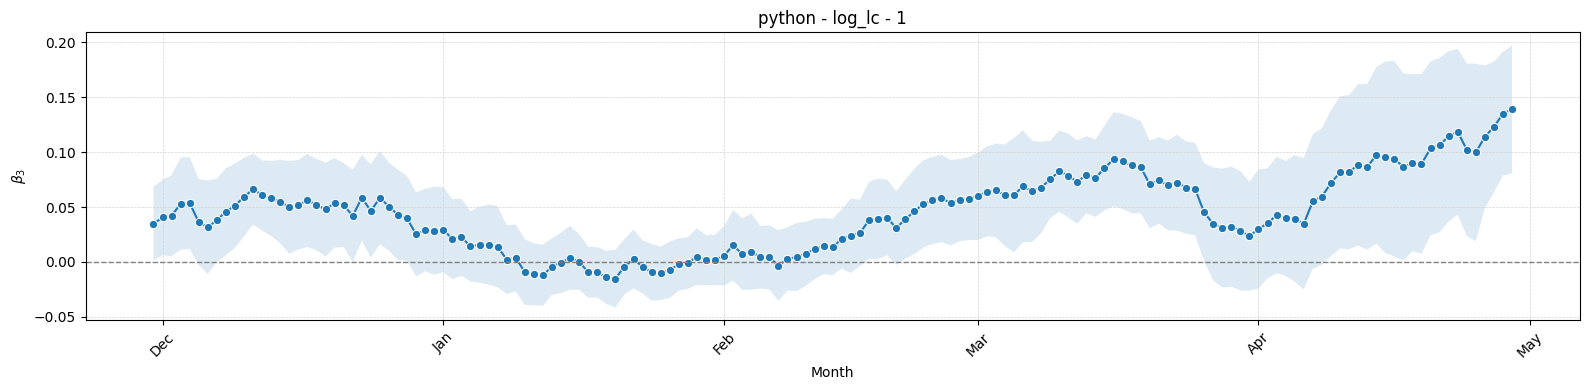

Processing: log_loc
Streak:  0.4768211920529801
Max:  0.15318601747215913
AUC:  0.05867326821479693


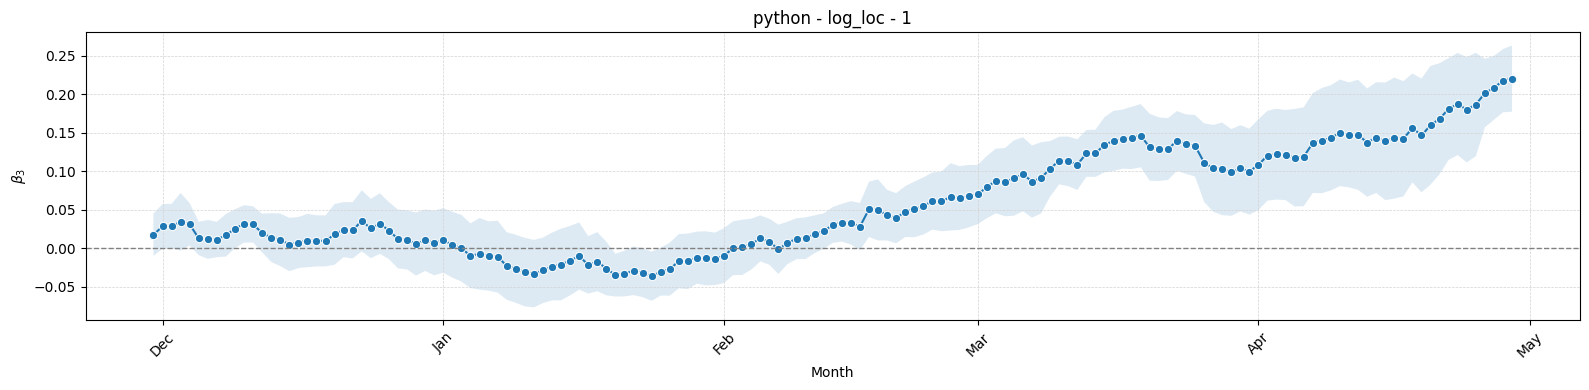

Processing: Medium
Streak:  0.13245033112582782
Max:  0.044547150366083234
AUC:  0.02191963996521633


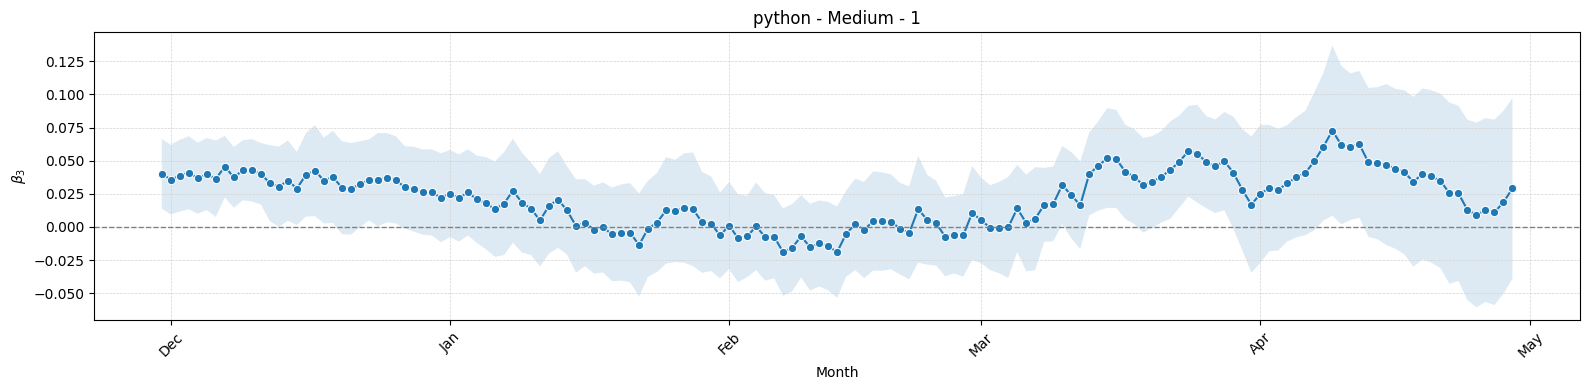

#Events: 86508
#Users: 7133
P  T
0  0    5101
   1    5038
1  0    3609
   1    2649
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.1390728476821192
Max:  0.06962393784645518
AUC:  0.04322234898163583


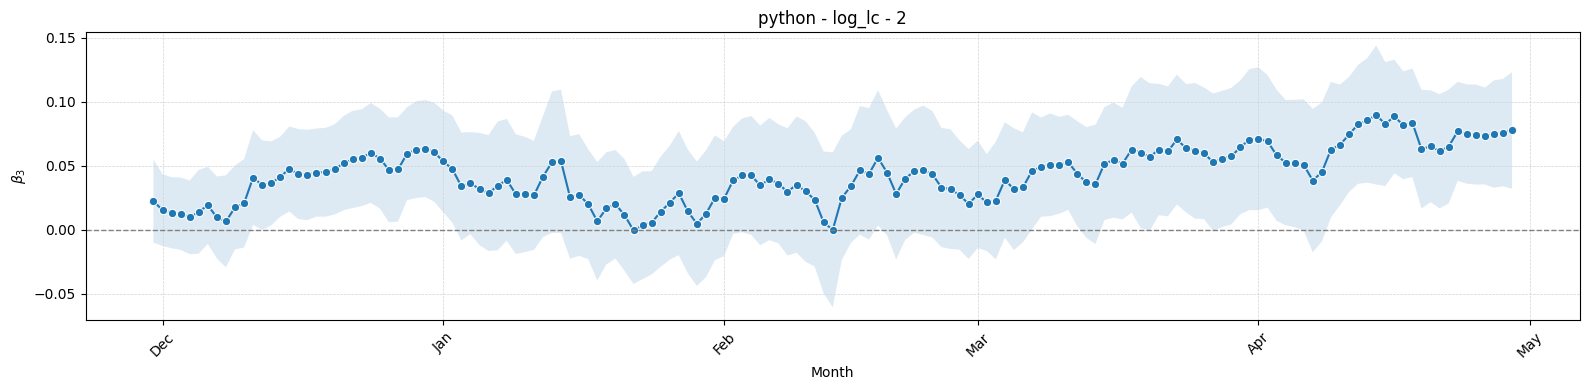

Processing: log_loc
Streak:  0.4966887417218543
Max:  0.1324925969486401
AUC:  0.0689834038305206


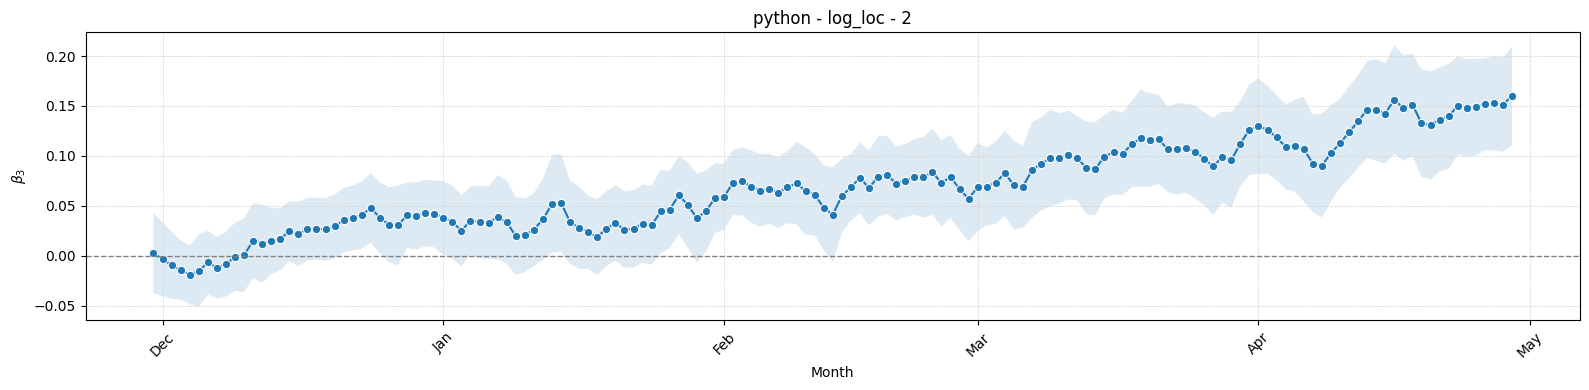

Processing: Medium
Streak:  0.0
Max:  0.01116571470687299
AUC:  -0.02183135522041604


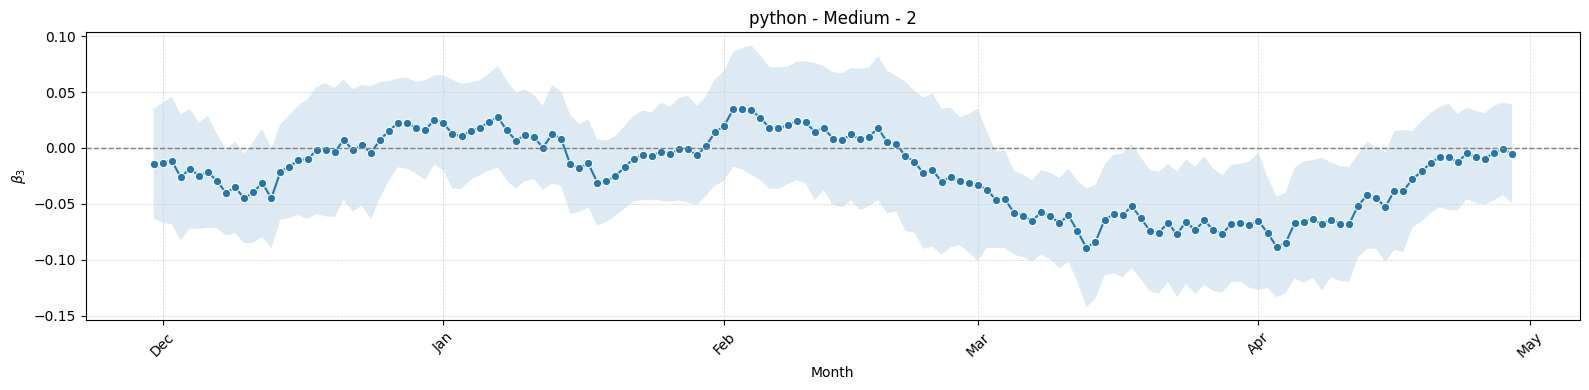

Processing: web


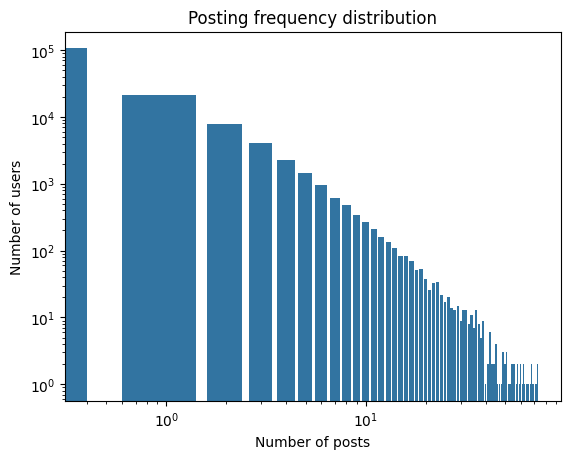

#Events: 80585
#Users: 64582
P  T
0  0    27069
   1    37513
1  0     5788
   1     4881
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.5827814569536424
Max:  0.14998807980426612
AUC:  0.08207373424831617


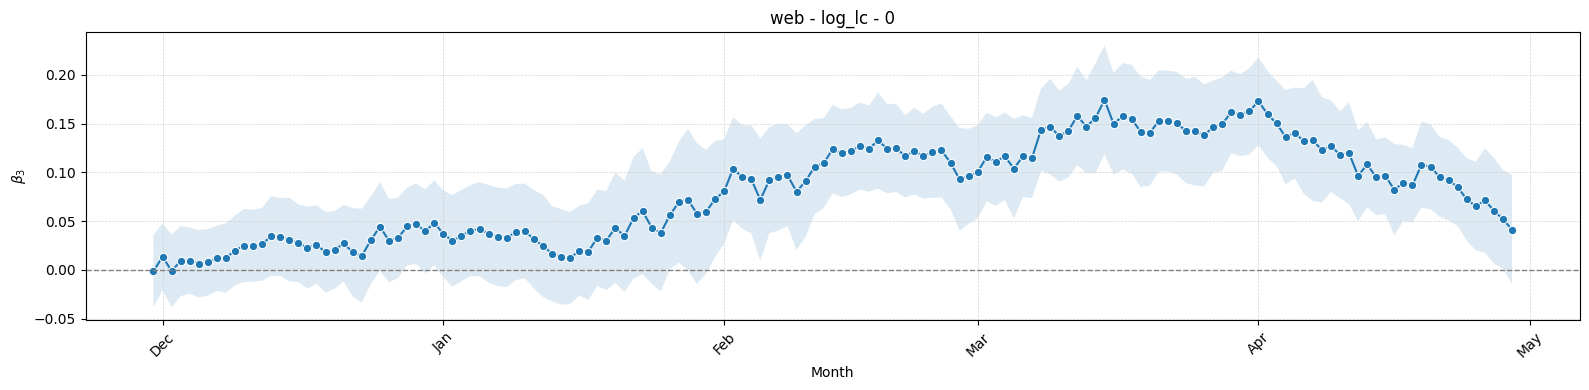

Processing: log_loc
Streak:  0.07947019867549669
Max:  0.07795257436613838
AUC:  0.010872719863696083


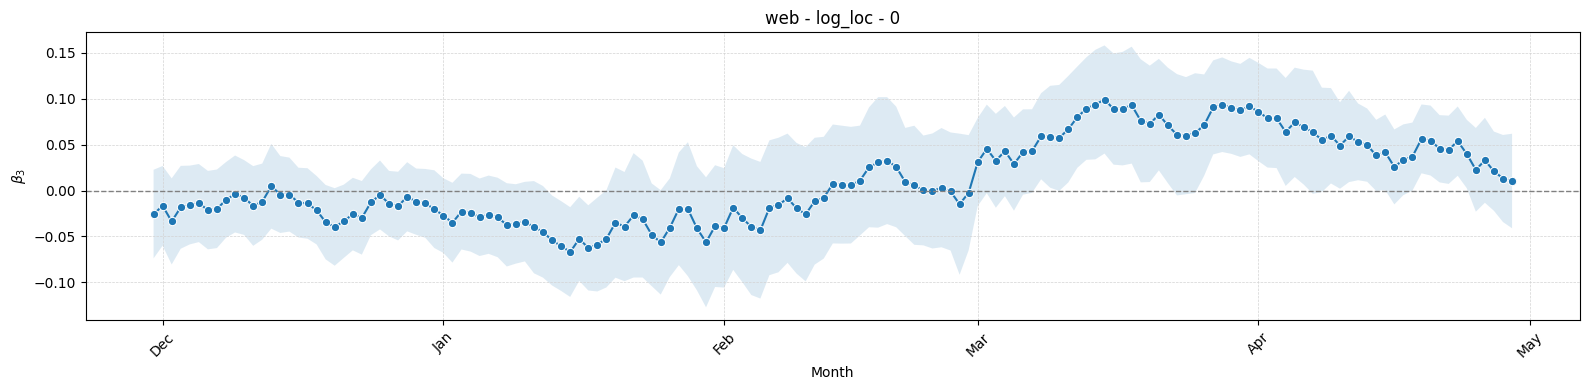

Processing: Medium
Streak:  0.152317880794702
Max:  0.08852952152935238
AUC:  0.02432601917502408


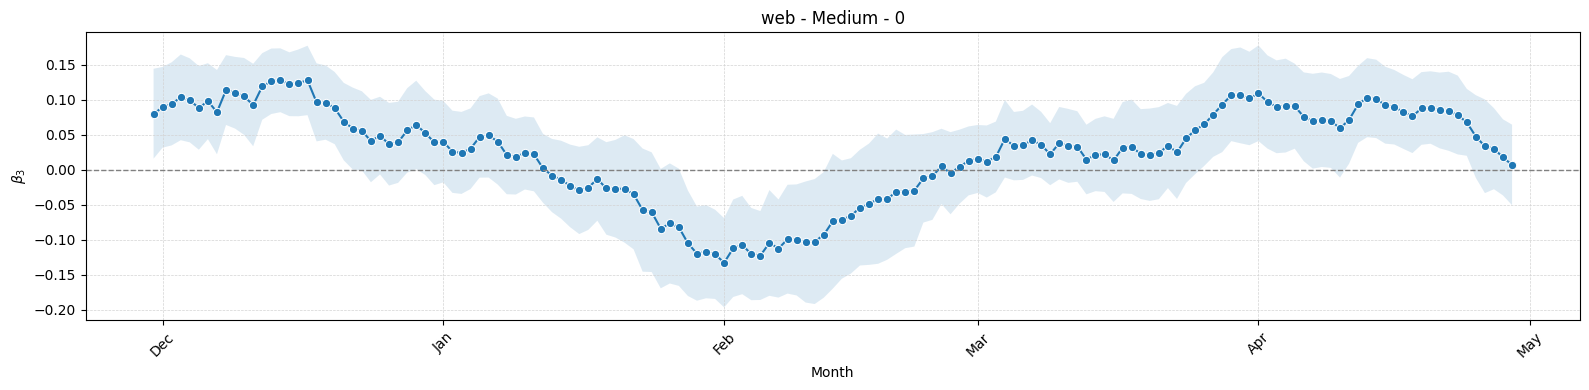

#Events: 172815
#Users: 75833
P  T
0  0    49364
   1    33292
1  0    14571
   1     8114
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.18543046357615894
Max:  0.0615720211102096
AUC:  0.020678406202515605


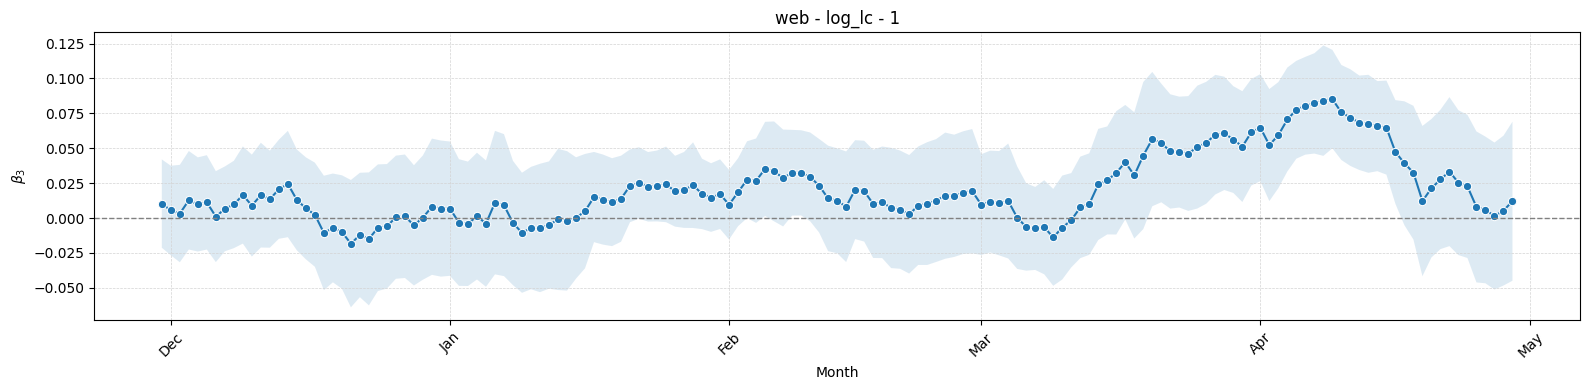

Processing: log_loc
Streak:  0.10596026490066225
Max:  0.05353679922808483
AUC:  0.02038090804349111


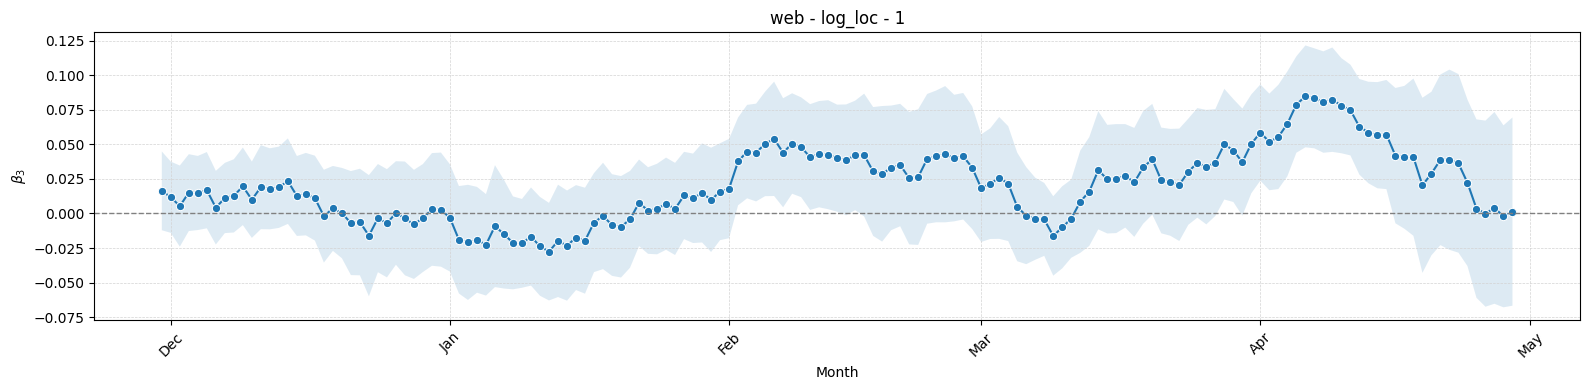

Processing: Medium
Streak:  0.1456953642384106
Max:  0.04710711779128543
AUC:  0.03173840933570328


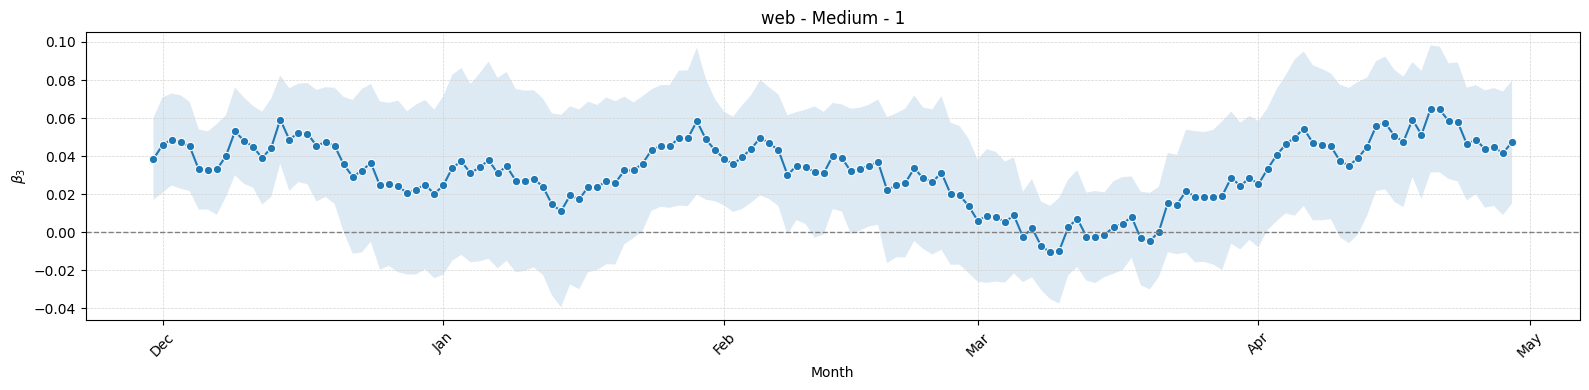

#Events: 93046
#Users: 6768
P  T
0  0    4910
   1    4773
1  0    3741
   1    2666
Name: OwnerUserId, dtype: int64
Processing: log_lc
Streak:  0.25165562913907286
Max:  0.09487854096901227
AUC:  0.05524985864366118


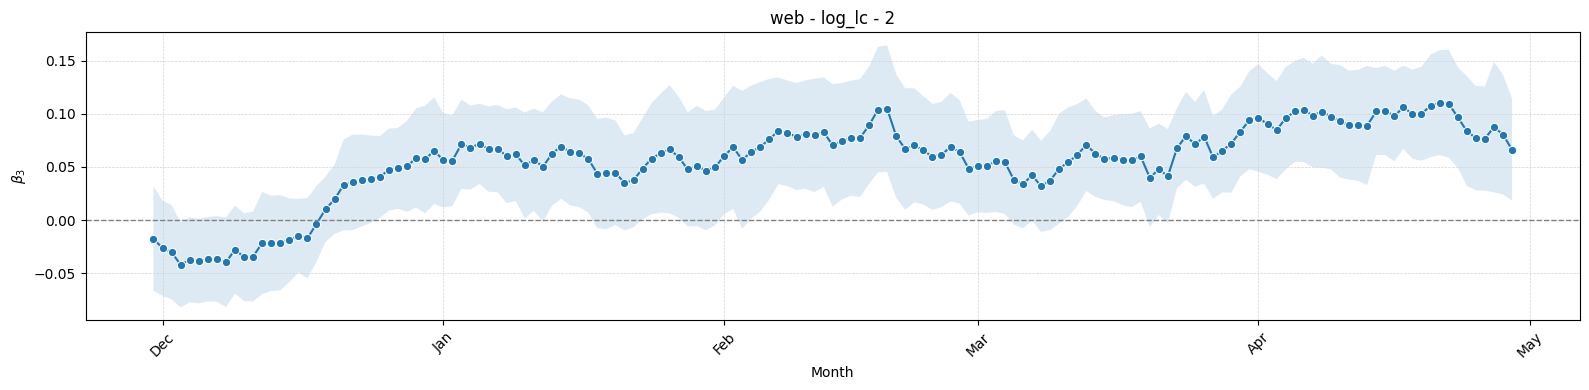

Processing: log_loc
Streak:  0.2119205298013245
Max:  0.07751991479972084
AUC:  0.039053497337563


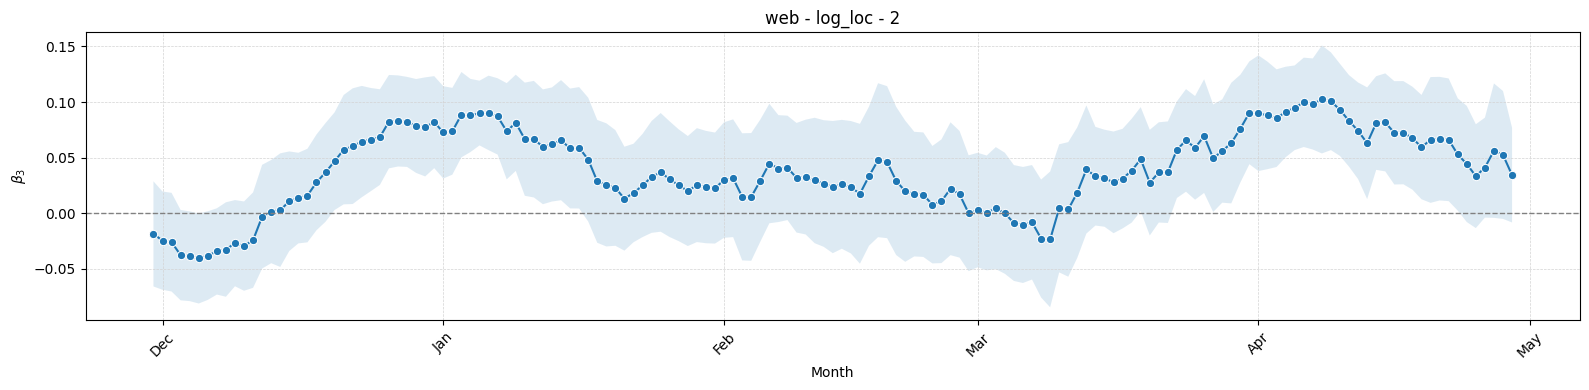

Processing: Medium
Streak:  0.1456953642384106
Max:  0.04938164713582265
AUC:  0.02376444453566767


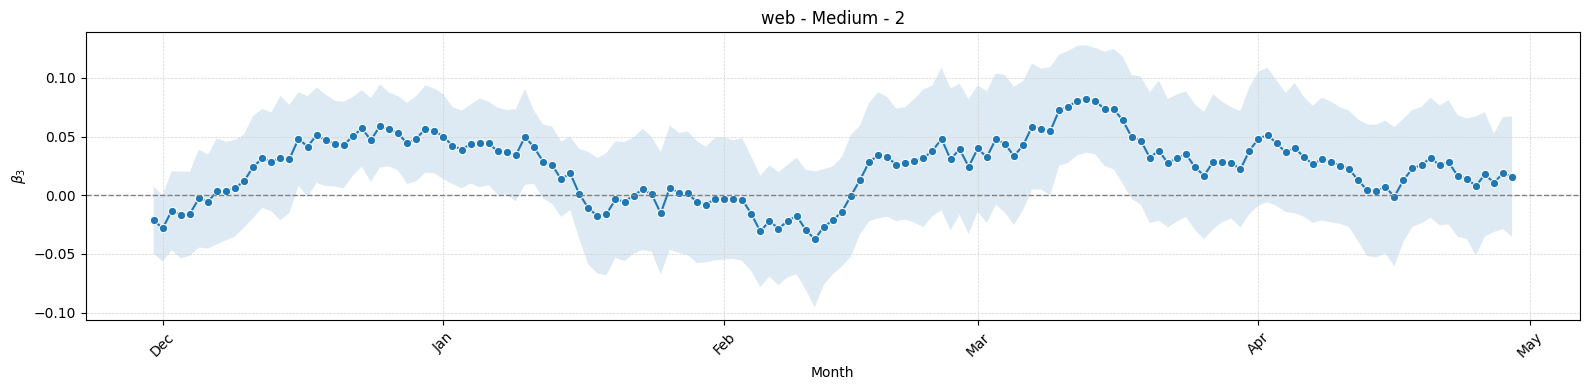

In [47]:
dfs = {'questions': questions, 'answers': answers} | tag_dfs
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}

for type in dfs:
    print(f'Processing: {type}')
    data = clean(dfs[type])
    up_df = join(dfs[type], users_df)

    counts = freq_dist(up_df[up_df['P'] == 0])
    sporadic_events, regular_events, power_events = groups(up_df, counts)

    for i, events in enumerate([sporadic_events, regular_events, power_events]):
        print('#Events:', len(events))
        print('#Users:', events['OwnerUserId'].nunique())

        
        print(events.groupby(['P', 'T'])['OwnerUserId'].nunique())

        daily = so.prepare_daily_data(events, outcomes[type])
        for outcome in outcomes[type]:
            print(f'Processing: {outcome}')
            try:
                res = regression(daily, outcome)
                print('Streak: ', so.effect_streak(res))
                print('Max: ', so.max_rolling_mean(res))
                print('AUC: ', so.auc(res) / len(res))
                so.plot_did(res, f'{type} - {outcome} - {i}', 'temp/temp.pdf')
            except Exception as e:
                print(f'Error processing {type} - {outcome} - {i}: {e}')